In [26]:
#Load dataset
import pandas as pd
from pathlib import Path
file_name = "/content/drive/MyDrive/AI Programming/Assignment 4/carefirst_support_escalation_dataset/carefirst_support_escalation_dataset.xlsx"
data_path = Path(file_name)
print("Current dataset path:", data_path)
print("File exists:", data_path.exists())

df = pd.read_excel(data_path)
print("Dataset loaded successfully!")

df.head()

Current dataset path: /content/drive/MyDrive/AI Programming/Assignment 4/carefirst_support_escalation_dataset/carefirst_support_escalation_dataset.xlsx
File exists: True
Dataset loaded successfully!


,Ticket_ID,Customer_Tier,Support_Channel,Issue_Category,Product_Type,Business_Size,Subscription_Plan,Response_Time_Hours,Prior_Tickets_90D,Customer_Value_USD,Days_Since_Purchase,Sentiment_Score,Agent_Workload,Resolution_Estimate_Hours,Last_CSAT_Score,Escalated
0,CF-10001,Gold,Web Form,Refund Request,Online Marketplace,Medium,Annual,NaN,1,2478.95,403,0.19,18.0,4.9,2,No
1,CF-10002,Gold,Web Form,Billing,Business Hardware,Large,Trial,3.8,0,3821.93,398,0.21,27.0,11.5,2,No
2,CF-10003,Basic,Web Form,Technical,Online Marketplace,Medium,Monthly,4.5,0,1839.55,346,0.75,5.0,10.1,3,No
3,CF-10004,Silver,Email,Refund Request,Subscription Service,Small,Annual,2.5,0,948.35,418,-1.00,15.0,5.1,4,No
4,CF-10005,Basic,Email,Technical,Online Marketplace,Small,Monthly,3.1,0,630.49,576,0.49,25.0,10.6,3,No


In [27]:
#Inspect dataset
df.shape

(253, 16)

In [28]:
df.columns

Index(['Ticket_ID', 'Customer_Tier', 'Support_Channel', 'Issue_Category',
       'Product_Type', 'Business_Size', 'Subscription_Plan',
       'Response_Time_Hours', 'Prior_Tickets_90D', 'Customer_Value_USD',
       'Days_Since_Purchase', 'Sentiment_Score', 'Agent_Workload',
       'Resolution_Estimate_Hours', 'Last_CSAT_Score', 'Escalated'],
      dtype='object')

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253 entries, 0 to 252
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Ticket_ID                  253 non-null    object 
 1   Customer_Tier              249 non-null    object 
 2   Support_Channel            253 non-null    object 
 3   Issue_Category             251 non-null    object 
 4   Product_Type               253 non-null    object 
 5   Business_Size              253 non-null    object 
 6   Subscription_Plan          253 non-null    object 
 7   Response_Time_Hours        248 non-null    float64
 8   Prior_Tickets_90D          253 non-null    int64  
 9   Customer_Value_USD         253 non-null    float64
 10  Days_Since_Purchase        253 non-null    int64  
 11  Sentiment_Score            249 non-null    float64
 12  Agent_Workload             251 non-null    float64
 13  Resolution_Estimate_Hours  253 non-null    float64

In [30]:
df.dtypes

,0
Ticket_ID,object
Customer_Tier,object
Support_Channel,object
Issue_Category,object
Product_Type,object
Business_Size,object
Subscription_Plan,object
Response_Time_Hours,float64
Prior_Tickets_90D,int64
Customer_Value_USD,float64


In [31]:
print("Missing values in each column:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values in each column:
Ticket_ID                    0
Customer_Tier                4
Support_Channel              0
Issue_Category               2
Product_Type                 0
Business_Size                0
Subscription_Plan            0
Response_Time_Hours          5
Prior_Tickets_90D            0
Customer_Value_USD           0
Days_Since_Purchase          0
Sentiment_Score              4
Agent_Workload               2
Resolution_Estimate_Hours    0
Last_CSAT_Score              0
Escalated                    0
dtype: int64

Number of duplicate rows:
3


In [32]:
#Understand the problem
business_problem = "The business problem is that support managers cannot manually review every ticket in detail."
ml_problem = "This is a classification problem because CareFirst wants to predict whether a support ticket is likely to be escalated."
prediction_goal = "Predict whether a support ticket is likely to be escalated: Yes or No."

print("Business Problem:\n", business_problem)
print("\nMachine Learning Problem:\n", ml_problem)
print("\nPrediction Goal:\n", prediction_goal)

Business Problem:
 The business problem is that support managers cannot manually review every ticket in detail.

Machine Learning Problem:
 This is a classification problem because CareFirst wants to predict whether a support ticket is likely to be escalated.

Prediction Goal:
 Predict whether a support ticket is likely to be escalated: Yes or No.


In [33]:
#Clean the dataset
df_clean = df.copy()
print("Original dataset shape:")
print(df_clean.shape)

Original dataset shape:
(253, 16)


In [34]:
df_clean = df_clean.drop_duplicates()
print("Dataset shape after removing duplicate rows:")
print(df_clean.shape)
print("\nNumber of duplicate rows after cleaning:")
print(df_clean.duplicated().sum())

Dataset shape after removing duplicate rows:
(250, 16)

Number of duplicate rows after cleaning:
0


In [36]:
numerical_columns = [
    'Response_Time_Hours',
    'Prior_Tickets_90D',
    'Customer_Value_USD',
    'Days_Since_Purchase',
    'Sentiment_Score',
    'Agent_Workload',
    'Resolution_Estimate_Hours',
    'Last_CSAT_Score'
]

categorical_columns = [
    'Customer_Tier',
    'Support_Channel',
    'Issue_Category',
    'Product_Type',
    'Business_Size',
    'Subscription_Plan'
]

for column in numerical_columns:
    median_value = df_clean[column].median()
    df_clean[column] = df_clean[column].fillna(median_value)

In [37]:
for column in categorical_columns:
    most_frequent_value = df_clean[column].mode()[0]
    df_clean[column] = df_clean[column].fillna(most_frequent_value)

In [38]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")
display(df_clean.head())

Missing values after cleaning:
Ticket_ID                    0
Customer_Tier                0
Support_Channel              0
Issue_Category               0
Product_Type                 0
Business_Size                0
Subscription_Plan            0
Response_Time_Hours          0
Prior_Tickets_90D            0
Customer_Value_USD           0
Days_Since_Purchase          0
Sentiment_Score              0
Agent_Workload               0
Resolution_Estimate_Hours    0
Last_CSAT_Score              0
Escalated                    0
dtype: int64

Cleaned dataset preview:


,Ticket_ID,Customer_Tier,Support_Channel,Issue_Category,Product_Type,Business_Size,Subscription_Plan,Response_Time_Hours,Prior_Tickets_90D,Customer_Value_USD,Days_Since_Purchase,Sentiment_Score,Agent_Workload,Resolution_Estimate_Hours,Last_CSAT_Score,Escalated
0,CF-10001,Gold,Web Form,Refund Request,Online Marketplace,Medium,Annual,2.75,1,2478.95,403,0.19,18.0,4.9,2,No
1,CF-10002,Gold,Web Form,Billing,Business Hardware,Large,Trial,3.80,0,3821.93,398,0.21,27.0,11.5,2,No
2,CF-10003,Basic,Web Form,Technical,Online Marketplace,Medium,Monthly,4.50,0,1839.55,346,0.75,5.0,10.1,3,No
3,CF-10004,Silver,Email,Refund Request,Subscription Service,Small,Annual,2.50,0,948.35,418,-1.00,15.0,5.1,4,No
4,CF-10005,Basic,Email,Technical,Online Marketplace,Small,Monthly,3.10,0,630.49,576,0.49,25.0,10.6,3,No


In [39]:
df = df_clean.copy()

In [40]:
#Define features and taget
target_column = "Escalated"
feature_columns = df.drop(columns=[target_column, 'Ticket_ID']).columns.tolist()

X = df[feature_columns]
y = df_clean[target_column]

print("Feature Columns:\n")
display(X.head())
print("Shape of X:", X.shape)


print("\nTarget Column:\n")
display(y.head())
print("Shape of y:", y.shape)
print("\nTarget values:")
print(df[target_column].value_counts())

Feature Columns:



,Customer_Tier,Support_Channel,Issue_Category,Product_Type,Business_Size,Subscription_Plan,Response_Time_Hours,Prior_Tickets_90D,Customer_Value_USD,Days_Since_Purchase,Sentiment_Score,Agent_Workload,Resolution_Estimate_Hours,Last_CSAT_Score
0,Gold,Web Form,Refund Request,Online Marketplace,Medium,Annual,2.75,1,2478.95,403,0.19,18.0,4.9,2
1,Gold,Web Form,Billing,Business Hardware,Large,Trial,3.80,0,3821.93,398,0.21,27.0,11.5,2
2,Basic,Web Form,Technical,Online Marketplace,Medium,Monthly,4.50,0,1839.55,346,0.75,5.0,10.1,3
3,Silver,Email,Refund Request,Subscription Service,Small,Annual,2.50,0,948.35,418,-1.00,15.0,5.1,4
4,Basic,Email,Technical,Online Marketplace,Small,Monthly,3.10,0,630.49,576,0.49,25.0,10.6,3


Shape of X: (250, 14)

Target Column:



,Escalated
0,No
1,No
2,No
3,No
4,No


Shape of y: (250,)

Target values:
Escalated
No     162
Yes     88
Name: count, dtype: int64


In [41]:
#Spit train and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:")
print(X_train.shape)

print("X_test shape:")
print(X_test.shape)

print("y_train shape:")
print(y_train.shape)

print("y_test shape:")
print(y_test.shape)

X_train shape:
(200, 14)
X_test shape:
(50, 14)
y_train shape:
(200,)
y_test shape:
(50,)


In [42]:
print("Target distribution in training set:")
print("-" * 50)

train_distribution = y_train.value_counts()

display(train_distribution)

print("\nTarget distribution in testing set:")
print("-" * 50)

test_distribution = y_test.value_counts()

display(test_distribution)

Target distribution in training set:
--------------------------------------------------


,count
Escalated,
No,130
Yes,70



Target distribution in testing set:
--------------------------------------------------


,count
Escalated,
No,32
Yes,18


In [45]:
#Preprocess
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
numerical_columns = [
    'Response_Time_Hours',
    'Prior_Tickets_90D',
    'Customer_Value_USD',
    'Days_Since_Purchase',
    'Sentiment_Score',
    'Agent_Workload',
    'Resolution_Estimate_Hours',
    'Last_CSAT_Score'
]

categorical_columns = [
    'Customer_Tier',
    'Support_Channel',
    'Issue_Category',
    'Product_Type',
    'Business_Size',
    'Subscription_Plan'
]

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", encoder, categorical_columns),
        ("numerical", "passthrough", numerical_columns)
    ]
)

print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [46]:
X_train_processed = preprocessor.fit_transform(X_train)
print("X_train preprocessing completed!")

X_test_processed = preprocessor.transform(X_test)
print("X_test preprocessing completed!")

print("Summary of preprocessing shapes:")
print("X_train before preprocessing:", X_train.shape)
print("X_train after preprocessing:", X_train_processed.shape)
print("X_test before preprocessing:", X_test.shape)
print("X_test after preprocessing:", X_test_processed.shape)

X_train preprocessing completed!
X_test preprocessing completed!
Summary of preprocessing shapes:
X_train before preprocessing: (200, 14)
X_train after preprocessing: (200, 33)
X_test before preprocessing: (50, 14)
X_test after preprocessing: (50, 33)


In [48]:
# Get the new feature names created from categorical variables
encoded_categorical_columns = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_columns)

# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_columns) + numerical_columns

print("Number of processed features:", len(processed_feature_names))

print(processed_feature_names)

Number of processed features: 33
['Customer_Tier_Basic', 'Customer_Tier_Enterprise', 'Customer_Tier_Gold', 'Customer_Tier_Silver', 'Support_Channel_Chat', 'Support_Channel_Email', 'Support_Channel_Phone', 'Support_Channel_Web Form', 'Issue_Category_Account Access', 'Issue_Category_Billing', 'Issue_Category_Delivery', 'Issue_Category_Product Setup', 'Issue_Category_Refund Request', 'Issue_Category_Technical', 'Product_Type_Business Hardware', 'Product_Type_Online Marketplace', 'Product_Type_Software', 'Product_Type_Subscription Service', 'Business_Size_Large', 'Business_Size_Medium', 'Business_Size_Small', 'Subscription_Plan_Annual', 'Subscription_Plan_Monthly', 'Subscription_Plan_Pay-as-you-go', 'Subscription_Plan_Trial', 'Response_Time_Hours', 'Prior_Tickets_90D', 'Customer_Value_USD', 'Days_Since_Purchase', 'Sentiment_Score', 'Agent_Workload', 'Resolution_Estimate_Hours', 'Last_CSAT_Score']


In [49]:
# Convert processed training data into a DataFrame
X_train_processed_df = pd.DataFrame(
    X_train_processed,
    columns = processed_feature_names,
    index=X_train.index
)

X_test_processed_df = pd.DataFrame(
    X_test_processed,
    columns=processed_feature_names,
    index=X_test.index
)

display(X_train_processed_df.head())

,Customer_Tier_Basic,Customer_Tier_Enterprise,Customer_Tier_Gold,Customer_Tier_Silver,Support_Channel_Chat,Support_Channel_Email,Support_Channel_Phone,Support_Channel_Web Form,Issue_Category_Account Access,Issue_Category_Billing,...,Subscription_Plan_Pay-as-you-go,Subscription_Plan_Trial,Response_Time_Hours,Prior_Tickets_90D,Customer_Value_USD,Days_Since_Purchase,Sentiment_Score,Agent_Workload,Resolution_Estimate_Hours,Last_CSAT_Score
214,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,3.9,3.0,502.37,348.0,-0.34,16.0,3.7,5.0
210,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,2.7,1.0,766.94,630.0,-0.33,24.0,1.8,3.0
225,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.7,4.0,2486.46,454.0,-0.68,20.0,5.3,3.0
169,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,6.8,0.0,3320.42,233.0,0.04,23.0,10.4,3.0
190,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,2.0,0.0,2414.22,455.0,0.76,23.0,7.3,1.0


In [91]:
#Training a Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
decision_tree_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

print("Decision Tree model has been created.")

Decision Tree model has been created.


In [92]:
decision_tree_model.fit(X_train_processed_df, y_train)
print("Decision Tree model has been trained successfully.")

Decision Tree model has been trained successfully.


In [93]:
print("Decision Tree Model Information")

print("-" * 50)

print(decision_tree_model)

Decision Tree Model Information
--------------------------------------------------
DecisionTreeClassifier(max_depth=4, random_state=42)


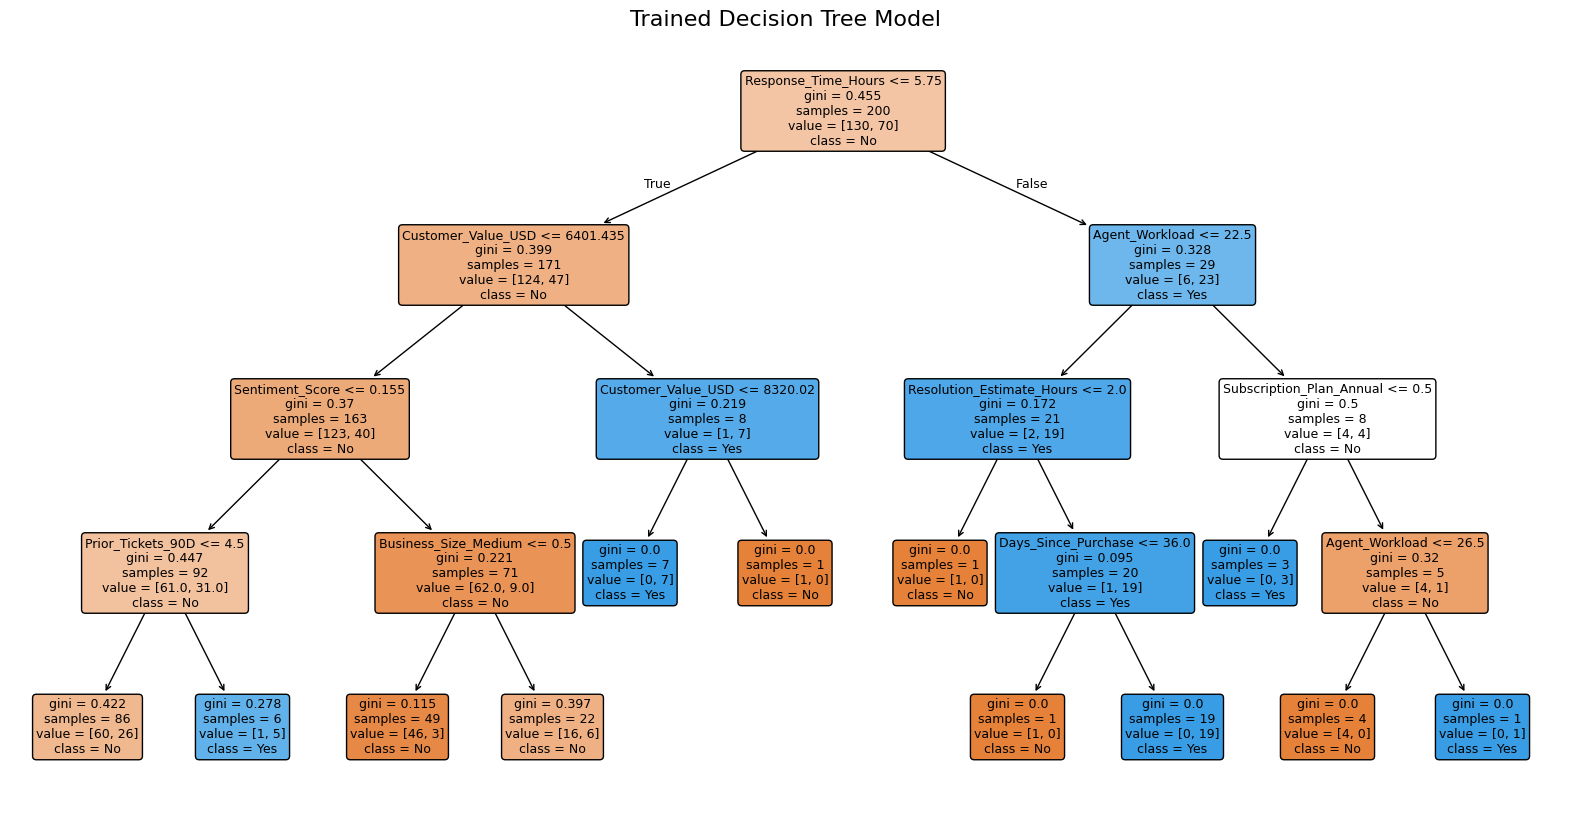

In [94]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=X_train_processed_df.columns,
    class_names=decision_tree_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Trained Decision Tree Model", fontsize=16)

plt.show()

In [95]:
tree_depth = decision_tree_model.get_depth()
tree_leaves = decision_tree_model.get_n_leaves()

print("Decision Tree depth:", tree_depth)
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 12


In [96]:
#Evaluating the Decision Tree Model
y_pred_dt = decision_tree_model.predict(X_test_processed_df)
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [97]:
dt_results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred_dt
})

print("Actual vs Predicted Values")

print("-" * 50)

display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,No,No
1,No,No
2,No,No
3,No,No
4,No,No
5,Yes,Yes
6,Yes,No
7,No,Yes
8,Yes,No
9,No,No


In [98]:
from sklearn.metrics import accuracy_score

dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Test Accuracy:")
print(dt_test_accuracy)

Decision Tree Test Accuracy:
0.6


In [99]:
y_train_pred_dt = decision_tree_model.predict(X_train_processed_df)

dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)

dt_test_accuracy = accuracy_score(y_test, y_pred_dt)

dt_accuracy_table = pd.DataFrame({
    "Evaluation Set": ["Training Set", "Testing Set"],
    "Accuracy": [dt_train_accuracy, dt_test_accuracy]
})

display(dt_accuracy_table)

,Evaluation Set,Accuracy
0,Training Set,0.82
1,Testing Set,0.60


In [100]:
#Confusion Matrix for Decision Tree
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [101]:
class_labels = ["No", "Yes"]

cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)

cm_dt_table = pd.DataFrame(
    cm_dt,
    index=["Actual No", "Actual Yes"],
    columns=["Predicted No", "Predicted Yes"]
)

print("Decision Tree Confusion Matrix")
print("-" * 50)
display(cm_dt_table)

Decision Tree Confusion Matrix
--------------------------------------------------


,Predicted No,Predicted Yes
Actual No,27,5
Actual Yes,15,3


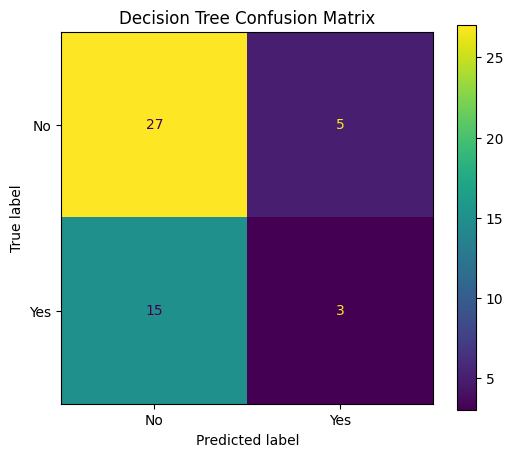

In [102]:
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_dt,
    display_labels=class_labels
)

disp.plot(ax=ax, values_format="d")

plt.title("Decision Tree Confusion Matrix")
plt.show()

In [103]:
#Accuracy, Precision, Recall, and F1-Score
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report

In [104]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)

print("Decision Tree Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.64      0.84      0.73        32
         Yes       0.38      0.17      0.23        18

    accuracy                           0.60        50
   macro avg       0.51      0.51      0.48        50
weighted avg       0.55      0.60      0.55        50



In [105]:
#Understanding Overfitting in Decision Trees
from sklearn.tree import DecisionTreeClassifier
overfit_tree_model = DecisionTreeClassifier(
    max_depth=None,
    random_state=42
)

overfit_tree_model.fit(X_train_processed_df, y_train)

print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [106]:
y_train_pred_overfit = overfit_tree_model.predict(X_train_processed_df)

y_test_pred_overfit = overfit_tree_model.predict(X_test_processed_df)

overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)

print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.4


In [107]:
print('''
Overfitting Assessment

A Decision Tree with no maximum depth (default) grows until every leaf is pure — it memorises the training data perfectly, resulting in 100% training accuracy.
When the model is then evaluated on the unseen test set, the accuracy typically drops significantly.

- If training accuracy ≈ 100% and testing accuracy is noticeably lower, this is a classic sign of overfitting.
- The model has memorised the training examples instead of learning generalisable patterns.
- To reduce overfitting, we can limit tree depth (max_depth), require a minimum number of samples per leaf (min_samples_leaf), or use a pruned/regularised tree.
''')


Overfitting Assessment

A Decision Tree with no maximum depth (default) grows until every leaf is pure — it memorises the training data perfectly, resulting in 100% training accuracy.
When the model is then evaluated on the unseen test set, the accuracy typically drops significantly.

- If training accuracy ≈ 100% and testing accuracy is noticeably lower, this is a classic sign of overfitting.
- The model has memorised the training examples instead of learning generalisable patterns.
- To reduce overfitting, we can limit tree depth (max_depth), require a minimum number of samples per leaf (min_samples_leaf), or use a pruned/regularised tree.

